# 01 — Data Exploration
Explore a SOLEY batch output: schema, fault distribution,
weather patterns, and the engineered features used by ML models.


## 1. Imports & setup

In [1]:
import sys, pathlib
# Add the library root to the Python path if running from the notebooks/ folder
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils       import setup_logging
from library.config      import BatchConfig
from library.data        import load_data_rf
from library.features    import add_features

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Point to your data
Set `DATA_DIR` to the folder that contains your SOLEY parquet files
(and optionally `batch_config.json`).


In [2]:
DATA_DIR   = "data"
OUTPUT_DIR = "outputs/exploration"
import pathlib
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


## 3. Auto-detect configuration

In [4]:
cfg = BatchConfig(DATA_DIR)
print(cfg)
print()
print(f"Array capacity : {cfg.array_kwp:.2f} kWp")
print(f"Locations      : {len(cfg.locations)}")
print(f"SCADA features : {len(cfg.scada_features)}")
print(f"Device features: {len(cfg.device_features)}")
print(f"Stress features: {len(cfg.stress_features)}")
print(f"Total features : {len(cfg.all_feature_cols)}")


  Config: array=5.34 kWp, 6 location(s)
  Columns: 11 SCADA, 14 device physics, 6 stress, 29 constant (excluded), 31 total features
BatchConfig(array_kwp=5.34, locations=6, features=31)

Array capacity : 5.34 kWp
Locations      : 6
SCADA features : 11
Device features: 14
Stress features: 6
Total features : 31


## 4. Load a sample of data (no subsampling limit)

In [5]:
# Load up to 200k rows for quick exploration
df_raw = load_data_rf(DATA_DIR, cfg, max_rows=200_000, engineer_features=False)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
print(df_raw.shape)
df_raw.head(3)


Loading 310 files (12 fault types) …
Balanced subsampling: ~16,666 rows per fault type
  … loaded 25 / 310 files
  … loaded 50 / 310 files
  … loaded 75 / 310 files
  … loaded 100 / 310 files
  … loaded 125 / 310 files
  … loaded 150 / 310 files
  … loaded 175 / 310 files
  … loaded 200 / 310 files
  … loaded 225 / 310 files
  … loaded 250 / 310 files
  … loaded 275 / 310 files
  … loaded 300 / 310 files
  … loaded 310 / 310 files
Total: 217,540 rows, 50 columns

Fault distribution:
  pid                                26,500  ( 12.2%)
  solder_fatigue                     24,500  ( 11.3%)
  connector_burnout                  16,665  (  7.7%)
  combo                              16,663  (  7.7%)
  sensor_drift                       16,659  (  7.7%)
  bypass_diode_short                 16,653  (  7.7%)
  cell_crack                         16,650  (  7.7%)
  curtailment                        16,650  (  7.7%)
  mppt_failure                       16,650  (  7.7%)
  none                    

,ac_power_kw,aging_factor,ambient_temp_c,aoi_correction_factor,aoi_deg,azimuth_deg,cell_temp_c,dc_ac_ratio,dc_power_kw,detailed_balance_efficiency_pct,...,stress_high_current,stress_power_transient,stress_thermal_cycling,stress_thermal_peak,stress_thermal_shock,tilt_deg,timestamp,vmpp_v,voc_v,wind_speed_ms
0,1.060025,0.995384,25.834221,0.897460,67.692467,180.0,27.112564,1.1,1.119734,16.685335,...,0.738085,0.049454,0.660018,0.633828,0.038784,24.1,2018-12-03 12:55:00,0.528453,0.622819,3.9
1,3.818125,0.996890,30.073332,0.999312,34.431297,180.0,45.486607,1.1,4.073073,17.718794,...,0.522358,0.865104,0.633274,0.664674,0.351483,24.1,2018-08-15 15:20:00,0.525844,0.642698,4.4
2,3.337174,0.998562,28.466148,1.000623,22.512604,180.0,37.358089,1.1,3.449977,18.058228,...,0.092760,0.725121,0.545997,0.586500,0.258893,24.1,2018-04-15 18:40:00,0.537200,0.648571,8.2


## 5. Schema & dtypes

In [6]:
df_raw.dtypes.to_frame("dtype")


,dtype
ac_power_kw,float32
aging_factor,float32
ambient_temp_c,float32
aoi_correction_factor,float32
aoi_deg,float32
azimuth_deg,float32
cell_temp_c,float32
dc_ac_ratio,float32
dc_power_kw,float32
detailed_balance_efficiency_pct,float32


## 6. Fault distribution

In [7]:
print("fault_active counts")
print(df_raw["fault_active"].value_counts())
print()
print("fault_type counts (faulted rows only)")
faulted = df_raw[df_raw["fault_active"]]
vc = faulted["fault_type"].value_counts()
print(vc)


fault_active counts
fault_active
True     150409
False     67131
Name: count, dtype: int64

fault_type counts (faulted rows only)
fault_type
pid                   26500
solder_fatigue        21498
combo                 16663
sensor_drift          16659
connector_burnout     14666
bypass_diode_short    14130
cell_crack            13800
string_failure        10225
mppt_failure           9846
sudden_soiling         4140
curtailment            2282
Name: count, dtype: int64


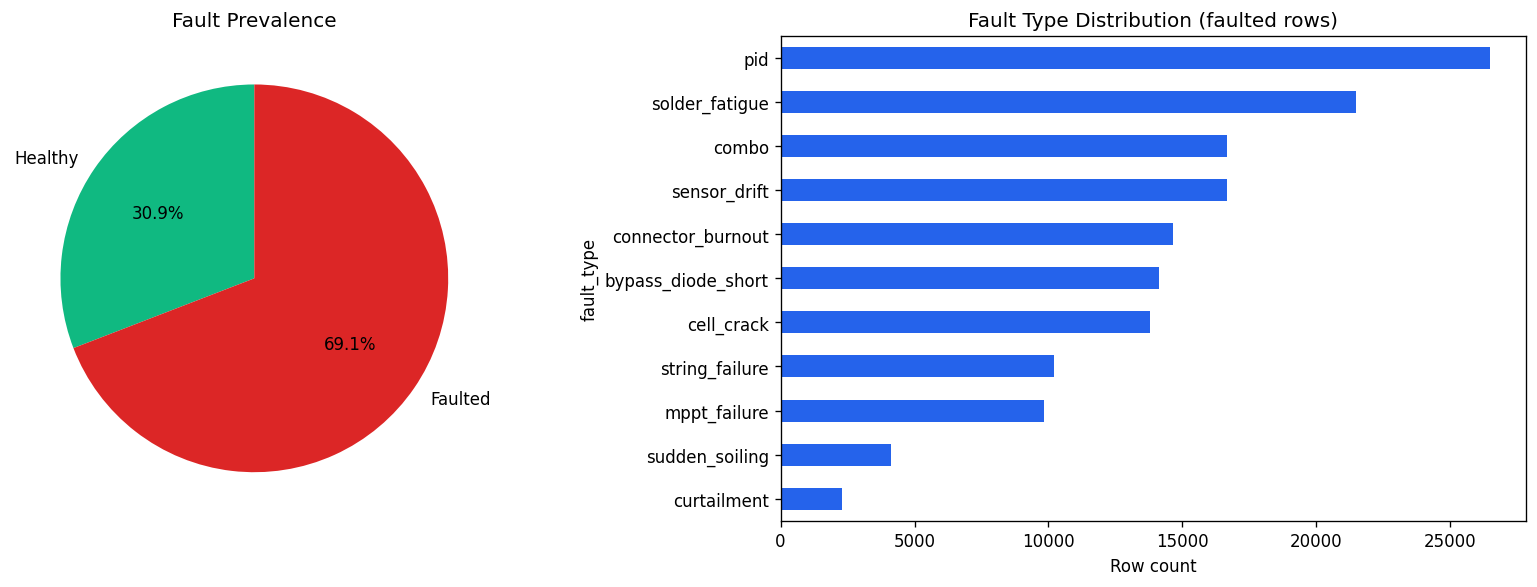

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fault prevalence
ax = axes[0]
labels = ["Healthy", "Faulted"]
sizes  = [len(df_raw) - len(faulted), len(faulted)]
ax.pie(sizes, labels=labels, autopct="%1.1f%%",
       colors=["#10b981", "#dc2626"], startangle=90)
ax.set_title("Fault Prevalence")

# Fault type breakdown
ax = axes[1]
vc.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Row count")
ax.set_title("Fault Type Distribution (faulted rows)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fault_distribution.png", bbox_inches="tight")
plt.show()


## 7. Temporal overview

In [9]:
if "sim_year" in df_raw.columns:
    year_counts = df_raw.groupby("sim_year")["fault_active"].agg(["sum", "count"])
    year_counts["fault_rate"] = year_counts["sum"] / year_counts["count"]
    display(year_counts)


,sum,count,fault_rate
sim_year,,,
1,12728,36409,0.349584
2,24105,36069,0.668302
3,26175,36637,0.714442
4,27138,36365,0.746267
5,28890,36002,0.802455
6,31373,36058,0.870070


## 8. Apply feature engineering & inspect new features

In [10]:
df = add_features(df_raw.copy(), cfg.array_kwp)
new_cols = ["hour_sin", "hour_cos", "doy_sin", "doy_cos",
            "performance_ratio", "pr_deviation",
            "dc_ac_power_ratio", "power_step"]
df[new_cols].describe().round(4)


After daytime filter: 213,260 rows


,hour_sin,hour_cos,doy_sin,doy_cos,performance_ratio,pr_deviation,dc_ac_power_ratio,power_step
count,213260.0000,213260.0000,213260.0000,213260.0000,213260.0000,213260.0000,213260.0000,213260.0000
mean,-0.6010,0.1051,0.0156,-0.0897,0.5921,0.8834,1.1447,0.3694
std,0.3845,0.6928,0.7071,0.7012,0.3239,0.5903,0.4157,0.2278
min,-1.0000,-1.0000,-1.0000,-1.0000,0.0000,0.0000,0.9859,0.0000
25%,-0.9239,-0.5556,-0.6933,-0.7883,0.4455,0.6609,1.0313,0.2219
50%,-0.7224,0.1736,0.0344,-0.1671,0.7357,1.0101,1.0509,0.3429
75%,-0.3624,0.8064,0.7236,0.5982,0.8418,1.1082,1.0807,0.5005
max,0.8434,1.0000,1.0000,1.0000,1.0256,3.0000,5.0000,1.0044


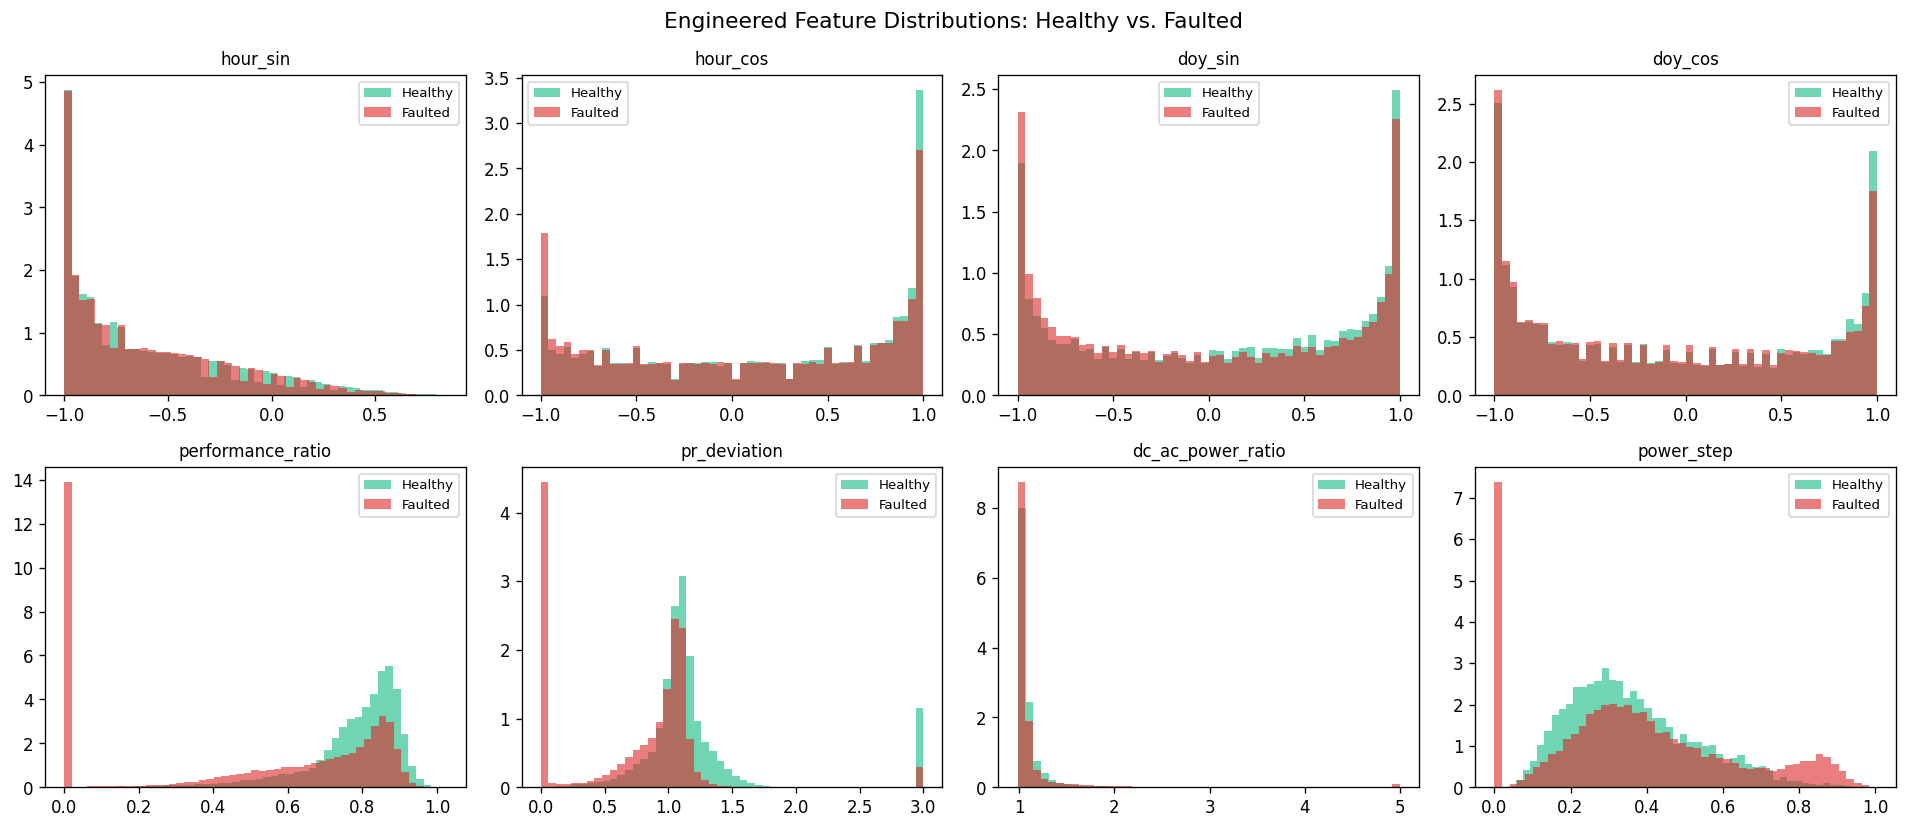

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, new_cols):
    healthy = df[~df["fault_active"]][col].dropna()
    bad     = df[ df["fault_active"]][col].dropna()
    ax.hist(healthy, bins=50, alpha=0.6, label="Healthy", color="#10b981",
            density=True)
    ax.hist(bad,     bins=50, alpha=0.6, label="Faulted", color="#dc2626",
            density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Engineered Feature Distributions: Healthy vs. Faulted",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", bbox_inches="tight")
plt.show()


## 9. Correlation heatmap (SCADA features)

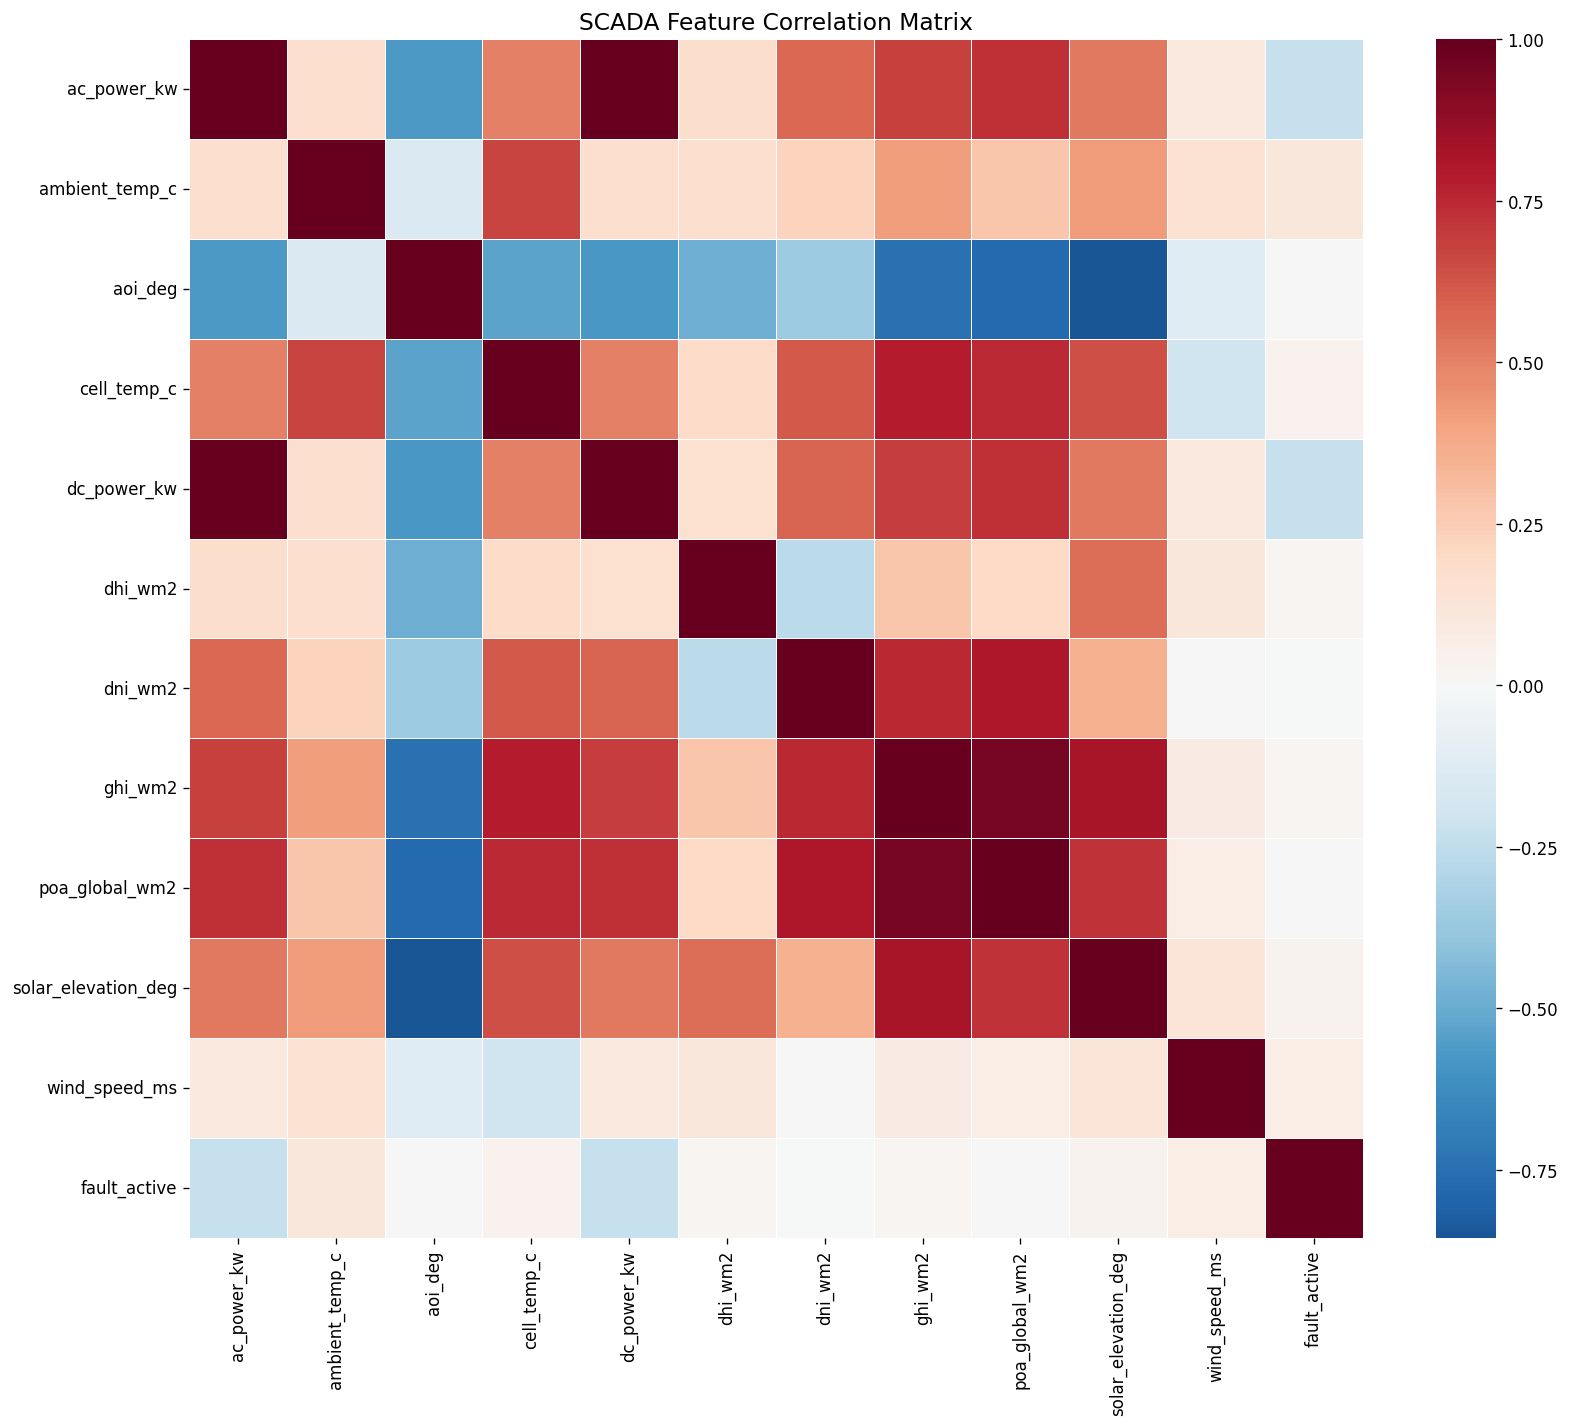

In [13]:
import seaborn as sns

scada_cols = [c for c in cfg.scada_features if c in df.columns]
corr = df[scada_cols + ["fault_active"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax)
ax.set_title("SCADA Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 10. Sample time-series: one run

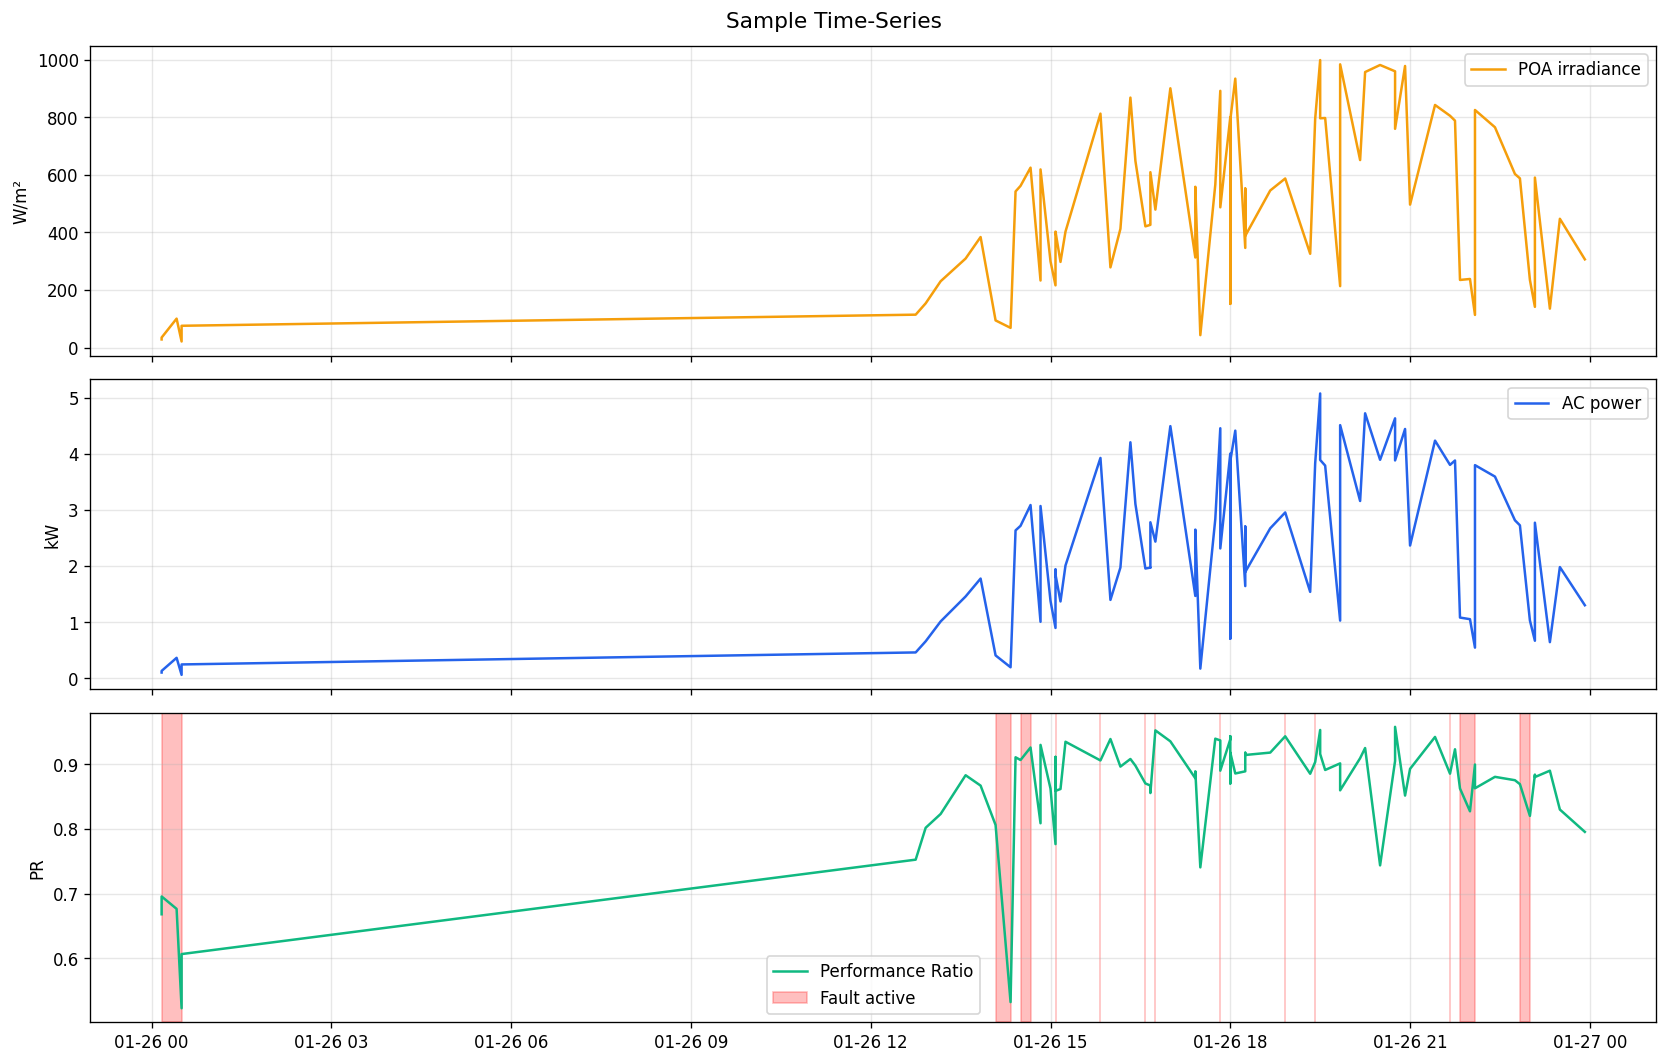

In [14]:
if "sim_day" in df.columns:
    # Pick one day from one run
    sample = df[df["sim_day"] == df["sim_day"].iloc[100]].copy()
    sample = sample.sort_values("timestamp")

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(sample["timestamp"], sample["poa_global_wm2"],
                 color="#f59e0b", label="POA irradiance")
    axes[0].set_ylabel("W/m²"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(sample["timestamp"], sample["ac_power_kw"],
                 color="#2563eb", label="AC power")
    axes[1].set_ylabel("kW"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(sample["timestamp"], sample["performance_ratio"],
                 color="#10b981", label="Performance Ratio")
    # Shade faulted periods
    if sample["fault_active"].any():
        fa = sample["fault_active"].values
        ts = sample["timestamp"].values
        axes[2].fill_between(ts, 0, 1,
                             where=fa, alpha=0.25, color="red",
                             label="Fault active", transform=axes[2].get_xaxis_transform())
    axes[2].set_ylabel("PR"); axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle("Sample Time-Series", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/sample_timeseries.png", bbox_inches="tight")
    plt.show()
else:
    print("sim_day column not present — skipping time-series plot.")
